<a href="https://colab.research.google.com/github/lxndrkrln/laba_ML/blob/main/Lab2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Данные: https://www.kaggle.com/c/titanic/data

### 1. Загрузка библиотек и датасета

In [30]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [31]:
data = pd.read_csv("train.csv")
data.head(10)

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S
5,6,0,3,"Moran, Mr. James",male,NaN,0,0,330877,8.4583,NaN,Q
6,7,0,1,"McCarthy, Mr. Timothy J",male,54.0,0,0,17463,51.8625,E46,S
7,8,0,3,"Palsson, Master. Gosta Leonard",male,2.0,3,1,349909,21.0750,NaN,S
8,9,1,3,"Johnson, Mrs. Oscar W (Elisabeth Vilhelmina Berg)",female,27.0,0,2,347742,11.1333,NaN,S
9,10,1,2,"Nasser, Mrs. Nicholas (Adele Achem)",female,14.0,1,0,237736,30.0708,NaN,C


In [32]:
data.shape

(891, 12)

In [33]:
data.dtypes

,0
PassengerId,int64
Survived,int64
Pclass,int64
Name,object
Sex,object
Age,float64
SibSp,int64
Parch,int64
Ticket,object
Fare,float64


# проверим есть ли пропущенные значения

In [34]:
data.isnull().sum()

,0
PassengerId,0
Survived,0
Pclass,0
Name,0
Sex,0
Age,177
SibSp,0
Parch,0
Ticket,0
Fare,0


Обработка пропусков в данных

Простые стратегии - удаление или заполнение нулями

Удаление колонок, содержащих пустые значения res = data.dropna(axis=1, how='any') Удаление строк, содержащих пустые значения res = data.dropna(axis=0, how='any')

In [35]:
# Удаление колонок, содержащих пустые значения
data_new_1 = data.dropna(axis=1, how='any')
(data.shape, data_new_1.shape)

((891, 12), (891, 9))

In [36]:
# Удаление строк, содержащих пустые значения
data_new_2 = data.dropna(axis=0, how='any')
(data.shape, data_new_2.shape)

((891, 12), (183, 12))

In [37]:
# проверим есть ли пропущенные значения
data_new_2.isnull().sum()

,0
PassengerId,0
Survived,0
Pclass,0
Name,0
Sex,0
Age,0
SibSp,0
Parch,0
Ticket,0
Fare,0


In [38]:
# Заполнение всех пропущенных значений нулями
# В данном случае это некорректно, так как нулями заполняются в том числе категориальные колонки
data_new_3 = data.fillna(0)
data_new_3.head(10)

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,0,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,0,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,0,S
5,6,0,3,"Moran, Mr. James",male,0.0,0,0,330877,8.4583,0,Q
6,7,0,1,"McCarthy, Mr. Timothy J",male,54.0,0,0,17463,51.8625,E46,S
7,8,0,3,"Palsson, Master. Gosta Leonard",male,2.0,3,1,349909,21.0750,0,S
8,9,1,3,"Johnson, Mrs. Oscar W (Elisabeth Vilhelmina Berg)",female,27.0,0,2,347742,11.1333,0,S
9,10,1,2,"Nasser, Mrs. Nicholas (Adele Achem)",female,14.0,1,0,237736,30.0708,0,C


"Внедрение значений" - импьютация (imputation)

Обработка пропусков в числовых данных

In [39]:
# Выберем числовые колонки с пропущенными значениями
# Цикл по колонкам датасета
total_count = data.shape[0]
num_cols = []
for col in data.columns:
    # Количество пустых значений
    temp_null_count = data[data[col].isnull()].shape[0]
    dt = str(data[col].dtype)
    if temp_null_count>0 and (dt=='float64' or dt=='int64'):
        num_cols.append(col)
        temp_perc = round((temp_null_count / total_count) * 100.0, 2)
        print('Колонка {}. Тип данных {}. Количество пустых значений {}, {}%.'.format(col, dt, temp_null_count, temp_perc))

Колонка Age. Тип данных float64. Количество пустых значений 177, 19.87%.


In [40]:
#Фильтр по колонкам с пропущенными значениями
data_num = data[num_cols]
data_num

,Age
0,22.0
1,38.0
2,26.0
3,35.0
4,35.0
...,...
886,27.0
887,19.0
888,NaN
889,26.0


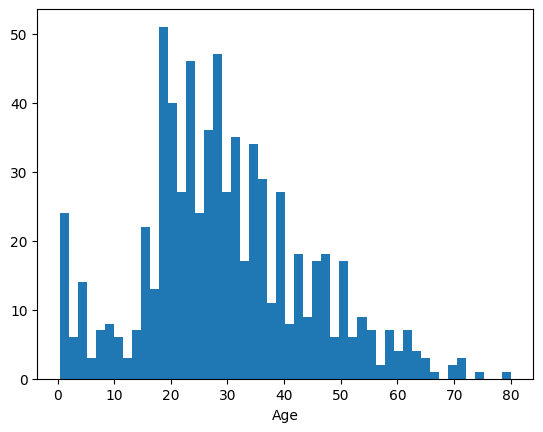

In [41]:
# Гистограмма по признакам
for col in data_num:
    plt.hist(data[col], 50)
    plt.xlabel(col)
    plt.show()

In [42]:
data_num_Age = data_num[['Age']]
data_num_Age.head()

,Age
0,22.0
1,38.0
2,26.0
3,35.0
4,35.0


In [43]:
from sklearn.impute import SimpleImputer
from sklearn.impute import MissingIndicator

In [99]:
# Фильтр для проверки заполнения пустых значений
indicator = MissingIndicator()
mask_missing_values_only = indicator.fit_transform(data_num_Age)
mask_missing_values_only[:10]

array([[False],
       [False],
       [False],
       [False],
       [False],
       [ True],
       [False],
       [False],
       [False],
       [False]])

С помощью класса SimpleImputer можно проводить импьютацию различными показателями центра распределения

In [45]:
strategies=['mean', 'median', 'most_frequent']
def test_num_impute(strategy_param):
    imp_num = SimpleImputer(strategy=strategy_param)
    data_num_imp = imp_num.fit_transform(data_num_Age)
    return data_num_imp[mask_missing_values_only]

In [46]:
strategies[0], test_num_impute(strategies[0])

('mean',
 array([29.69911765, 29.69911765, 29.69911765, 29.69911765, 29.69911765,
        29.69911765, 29.69911765, 29.69911765, 29.69911765, 29.69911765,
        29.69911765, 29.69911765, 29.69911765, 29.69911765, 29.69911765,
        29.69911765, 29.69911765, 29.69911765, 29.69911765, 29.69911765,
        29.69911765, 29.69911765, 29.69911765, 29.69911765, 29.69911765,
        29.69911765, 29.69911765, 29.69911765, 29.69911765, 29.69911765,
        29.69911765, 29.69911765, 29.69911765, 29.69911765, 29.69911765,
        29.69911765, 29.69911765, 29.69911765, 29.69911765, 29.69911765,
        29.69911765, 29.69911765, 29.69911765, 29.69911765, 29.69911765,
        29.69911765, 29.69911765, 29.69911765, 29.69911765, 29.69911765,
        29.69911765, 29.69911765, 29.69911765, 29.69911765, 29.69911765,
        29.69911765, 29.69911765, 29.69911765, 29.69911765, 29.69911765,
        29.69911765, 29.69911765, 29.69911765, 29.69911765, 29.69911765,
        29.69911765, 29.69911765, 29.69911

In [47]:
strategies[1], test_num_impute(strategies[1])

('median',
 array([28., 28., 28., 28., 28., 28., 28., 28., 28., 28., 28., 28., 28.,
        28., 28., 28., 28., 28., 28., 28., 28., 28., 28., 28., 28., 28.,
        28., 28., 28., 28., 28., 28., 28., 28., 28., 28., 28., 28., 28.,
        28., 28., 28., 28., 28., 28., 28., 28., 28., 28., 28., 28., 28.,
        28., 28., 28., 28., 28., 28., 28., 28., 28., 28., 28., 28., 28.,
        28., 28., 28., 28., 28., 28., 28., 28., 28., 28., 28., 28., 28.,
        28., 28., 28., 28., 28., 28., 28., 28., 28., 28., 28., 28., 28.,
        28., 28., 28., 28., 28., 28., 28., 28., 28., 28., 28., 28., 28.,
        28., 28., 28., 28., 28., 28., 28., 28., 28., 28., 28., 28., 28.,
        28., 28., 28., 28., 28., 28., 28., 28., 28., 28., 28., 28., 28.,
        28., 28., 28., 28., 28., 28., 28., 28., 28., 28., 28., 28., 28.,
        28., 28., 28., 28., 28., 28., 28., 28., 28., 28., 28., 28., 28.,
        28., 28., 28., 28., 28., 28., 28., 28., 28., 28., 28., 28., 28.,
        28., 28., 28., 28., 28., 28., 28

In [48]:
strategies[2], test_num_impute(strategies[2])

('most_frequent',
 array([24., 24., 24., 24., 24., 24., 24., 24., 24., 24., 24., 24., 24.,
        24., 24., 24., 24., 24., 24., 24., 24., 24., 24., 24., 24., 24.,
        24., 24., 24., 24., 24., 24., 24., 24., 24., 24., 24., 24., 24.,
        24., 24., 24., 24., 24., 24., 24., 24., 24., 24., 24., 24., 24.,
        24., 24., 24., 24., 24., 24., 24., 24., 24., 24., 24., 24., 24.,
        24., 24., 24., 24., 24., 24., 24., 24., 24., 24., 24., 24., 24.,
        24., 24., 24., 24., 24., 24., 24., 24., 24., 24., 24., 24., 24.,
        24., 24., 24., 24., 24., 24., 24., 24., 24., 24., 24., 24., 24.,
        24., 24., 24., 24., 24., 24., 24., 24., 24., 24., 24., 24., 24.,
        24., 24., 24., 24., 24., 24., 24., 24., 24., 24., 24., 24., 24.,
        24., 24., 24., 24., 24., 24., 24., 24., 24., 24., 24., 24., 24.,
        24., 24., 24., 24., 24., 24., 24., 24., 24., 24., 24., 24., 24.,
        24., 24., 24., 24., 24., 24., 24., 24., 24., 24., 24., 24., 24.,
        24., 24., 24., 24., 24., 

Более сложная функция, которая позволяет задавать колонку и вид импьютации

In [49]:
def test_num_impute_col(dataset, column, strategy_param):
    temp_data = dataset[[column]]

    indicator = MissingIndicator()
    mask_missing_values_only = indicator.fit_transform(temp_data)

    imp_num = SimpleImputer(strategy=strategy_param)
    data_num_imp = imp_num.fit_transform(temp_data)

    filled_data = data_num_imp[mask_missing_values_only]

    return column, strategy_param, filled_data.size, filled_data[0], filled_data[filled_data.size-1]

In [50]:
data[['Age']].describe()

,Age
count,714.000000
mean,29.699118
std,14.526497
min,0.420000
25%,20.125000
50%,28.000000
75%,38.000000
max,80.000000


In [51]:
test_num_impute_col(data, 'Age', strategies[0])

('Age',
 'mean',
 177,
 np.float64(29.69911764705882),
 np.float64(29.69911764705882))

In [52]:
test_num_impute_col(data, 'Age', strategies[1])

('Age', 'median', 177, np.float64(28.0), np.float64(28.0))

In [53]:
test_num_impute_col(data, 'Age', strategies[2])

('Age', 'most_frequent', 177, np.float64(24.0), np.float64(24.0))

Обработка пропусков в категориальных данных

In [54]:
# Выберем категориальные колонки с пропущенными значениями
# Цикл по колонкам датасета
cat_cols = []
for col in data.columns:
    # Количество пустых значений
    temp_null_count = data[data[col].isnull()].shape[0]
    dt = str(data[col].dtype)
    if temp_null_count>0 and ((dt=='object') or (dt=='str')):
        cat_cols.append(col)
        temp_perc = round((temp_null_count / total_count) * 100.0, 2)
        print('Колонка {}. Тип данных {}. Количество пустых значений {}, {}%.'.format(col, dt, temp_null_count, temp_perc))

Колонка Cabin. Тип данных object. Количество пустых значений 687, 77.1%.
Колонка Embarked. Тип данных object. Количество пустых значений 2, 0.22%.


In [55]:
cat_temp_data = data[['Sex']]
cat_temp_data.head()

,Sex
0,male
1,female
2,female
3,female
4,male


In [56]:
cat_temp_data[cat_temp_data['Sex'].isnull()].shape

(0, 1)

Импьютация наиболее частыми значениями

In [57]:
most_frequent = data['Sex'].mode()[0]
print(f"Самое частое значение: {most_frequent}")

Самое частое значение: male


In [100]:
imp2 = SimpleImputer(missing_values=np.nan, strategy='most_frequent')
data_imp2 = imp2.fit_transform(cat_temp_data)
data_imp2[:10]

array([['male'],
       ['female'],
       ['female'],
       ['female'],
       ['male'],
       ['male'],
       ['male'],
       ['male'],
       ['female'],
       ['female']], dtype=object)

In [59]:
np.unique(data_imp2)

array(['female', 'male'], dtype=object)

Импьютация константой

In [101]:
imp3 = SimpleImputer(missing_values=np.nan, strategy='constant', fill_value='Unknown')
data_imp3 = imp3.fit_transform(cat_temp_data)
data_imp3[:10]

array([['male'],
       ['female'],
       ['female'],
       ['female'],
       ['male'],
       ['male'],
       ['male'],
       ['male'],
       ['female'],
       ['female']], dtype=object)

In [62]:
np.unique(data_imp3)

array(['female', 'male'], dtype=object)

In [63]:
data_imp3[data_imp3=='Unknown'].size

0

Преобразование категориальных признаков в числовые

In [65]:
cat_enc = pd.DataFrame({'Sex_New':data_imp2.T[0]})
cat_enc

,Sex_New
0,male
1,female
2,female
3,female
4,male
...,...
886,male
887,female
888,female
889,male


Кодирование категорий целочисленными значениями (label encoding)

В этом случае уникальные значения категориального признака кодируются целыми числами.

В scikit-learn для такого кодирования используется два класса :

LabelEncoder - который ориентирован на применение к одному признаку. Этот класс прежде всего предназначен для кодирования целевого признака, но может быть также использован для последовательного кодирования отдельных нецелевых признаков.

OrdinalEncoder - который ориентирован на применение к матрице объект-признак, то есть для кодирования матрицы нецелевых признаков.

In [66]:
from sklearn.preprocessing import LabelEncoder

In [67]:
cat_enc['Sex_New'].unique()

array(['male', 'female'], dtype=object)

In [68]:
cat_enc

,Sex_New
0,male
1,female
2,female
3,female
4,male
...,...
886,male
887,female
888,female
889,male


In [69]:
le = LabelEncoder()
cat_enc_le = cat_enc.copy()
cat_enc_le ['cat_le'] = le.fit_transform(cat_enc['Sex_New'])
cat_enc_le

,Sex_New,cat_le
0,male,1
1,female,0
2,female,0
3,female,0
4,male,1
...,...,...
886,male,1
887,female,0
888,female,0
889,male,1


In [70]:
le.classes_

array(['female', 'male'], dtype=object)

In [71]:
np.unique(cat_enc_le['cat_le'])

array([0, 1])

В этом примере видно, что перед кодированием уникальные значения признака сортируются в лексикографиеском порядке

In [72]:
le.inverse_transform([0, 1])

array(['female', 'male'], dtype=object)

Использование OrdinalEncoder

In [73]:
from sklearn.preprocessing import OrdinalEncoder

In [74]:
data.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [75]:
data_oe = data[['Sex', 'Pclass', 'Embarked']]
data_oe.head()

,Sex,Pclass,Embarked
0,male,3,S
1,female,1,C
2,female,3,S
3,female,1,S
4,male,3,S


In [77]:
imp4 = SimpleImputer(missing_values=np.nan, strategy='constant', fill_value='Unknown')
data_oe_filled = imp4.fit_transform(data_oe)
data_oe_filled

array([['male', 3, 'S'],
       ['female', 1, 'C'],
       ['female', 3, 'S'],
       ...,
       ['female', 3, 'S'],
       ['male', 1, 'C'],
       ['male', 3, 'Q']], dtype=object)

In [78]:
oe = OrdinalEncoder()
cat_enc_oe = oe.fit_transform(data_oe_filled)
cat_enc_oe

array([[1., 2., 2.],
       [0., 0., 0.],
       [0., 2., 2.],
       ...,
       [0., 2., 2.],
       [1., 0., 0.],
       [1., 2., 1.]])

In [79]:
# Уникальные значения 1 признака
np.unique(cat_enc_oe[:, 0])

array([0., 1.])

In [80]:
# Уникальные значения 2 признака
np.unique(cat_enc_oe[:, 1])

array([0., 1., 2.])

In [81]:
# Уникальные значения 3 признака
np.unique(cat_enc_oe[:, 2])

array([0., 1., 2., 3.])

In [82]:
# Наименования категорий в соответствии с порядковыми номерами
oe.categories_

[array(['female', 'male'], dtype=object),
 array([1, 2, 3], dtype=object),
 array(['C', 'Q', 'S', 'Unknown'], dtype=object)]

In [83]:
# Обратное преобразование
oe.inverse_transform(cat_enc_oe)

array([['male', 3, 'S'],
       ['female', 1, 'C'],
       ['female', 3, 'S'],
       ...,
       ['female', 3, 'S'],
       ['male', 1, 'C'],
       ['male', 3, 'Q']], dtype=object)

Проблемы использования LabelEncoder и OrdinalEncoder

Необходимо отметить, что LabelEncoder и OrdinalEncoder могут использоваться только для категориальных признаков в номинальных шкалах (для которых отсутствует порядок), например города, страны, названия рек и т.д.

Это связано с тем, что задать какой-либо порядок при кодировании с помощью LabelEncoder и OrdinalEncoder невозможно, они сортируют категории в лексикографическом порядке.

При этом кодирование целыми числами создает фиктивное отношение порядка (1 < 2 < 3 < ...) которого не было в исходных номинальных шкалах. Данное отношение порядка может негативно повлиять на построение модели машинного обучения.

Кодирование категорий наборами бинарных значений - one-hot encoding

В этом случае каждое уникальное значение признака становится новым отдельным признаком.

In [84]:
from sklearn.preprocessing import OneHotEncoder

In [85]:
ohe = OneHotEncoder()
cat_enc_ohe = ohe.fit_transform(cat_enc[['Sex_New']])
cat_enc.shape

(891, 1)

In [86]:
cat_enc_ohe.shape

(891, 2)

In [87]:
cat_enc_ohe

<Compressed Sparse Row sparse matrix of dtype 'float64'
	with 891 stored elements and shape (891, 2)>

In [89]:
cat_enc_ohe.todense()[0:10]

matrix([[0., 1.],
        [1., 0.],
        [1., 0.],
        [1., 0.],
        [0., 1.],
        [0., 1.],
        [0., 1.],
        [0., 1.],
        [1., 0.],
        [1., 0.]])

In [90]:
cat_enc.head(10)

,Sex_New
0,male
1,female
2,female
3,female
4,male
5,male
6,male
7,male
8,female
9,female


Pandas get_dummies - быстрый вариант one-hot кодирования

In [91]:
pd.get_dummies(cat_enc).head()

,Sex_New_female,Sex_New_male
0,False,True
1,True,False
2,True,False
3,True,False
4,False,True


In [92]:
pd.get_dummies(cat_temp_data, dummy_na=True).head()

,Sex_female,Sex_male,Sex_nan
0,False,True,False
1,True,False,False
2,True,False,False
3,True,False,False
4,False,True,False


Масштабирование данных

In [93]:
from sklearn.preprocessing import MinMaxScaler, StandardScaler

MinMax масштабирование

In [94]:
sc1 = MinMaxScaler()
sc1_data = sc1.fit_transform(data[['Age']])

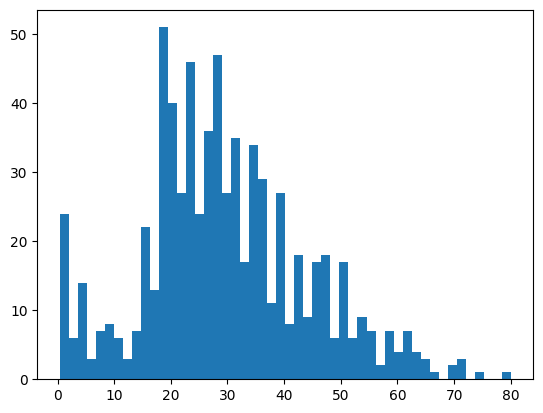

In [95]:
plt.hist(data['Age'], 50)
plt.show()

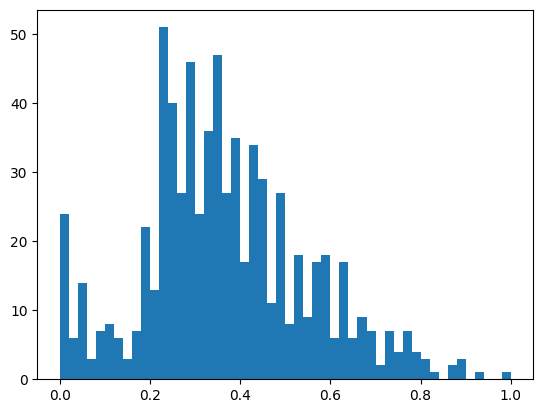

In [96]:
plt.hist(sc1_data, 50)
plt.show()

Масштабирование данных на основе Z-оценки - StandardScaler

In [97]:
sc2 = StandardScaler()
sc2_data = sc2.fit_transform(data[['Age']])

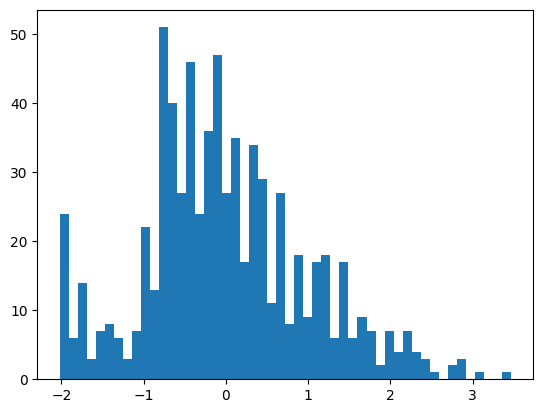

In [98]:
plt.hist(sc2_data, 50)
plt.show()